In [1]:
# This allows us to import from all folders one level up from notebooks folder - run 1 time
import sys
from pathlib import Path

print('All paths pre-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")
print('-'*100)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
print('All paths post-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")


All paths pre-append
0: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python311.zip
1: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11
2: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/site-packages
----------------------------------------------------------------------------------------------------
All paths post-append
0: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python311.zip
1: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11
2: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/site-packages
5: /Users/irabandutta/Developer/2026-0

# **Imports**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.datasets.cifar10 import load_cifar10

# **Load CIFAR10 Data**

In [3]:
cv_data_root_path = Path("/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data")
cifar10_path = cv_data_root_path / "cifar10"

X_train, Y_train, X_test, Y_test, label_map = load_cifar10(cifar10_path)

print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)
print('-'*50)
for k, v in label_map.items():
    print(f"{k}: {v}")

(50000, 3, 32, 32) (50000,)
(10000, 3, 32, 32) (10000,)
--------------------------------------------------
num_cases_per_batch: 10000
label_names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_vis: 3072


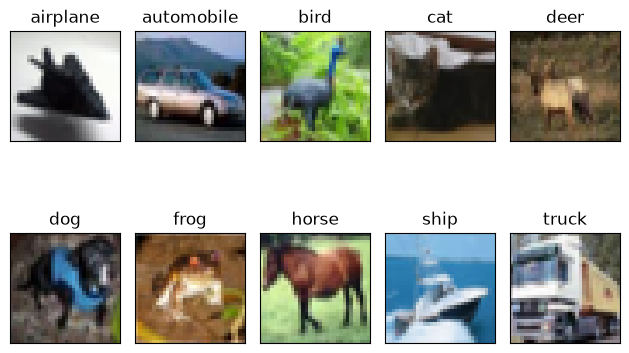

In [4]:
# Viewing 1 image from all classes

fig, ax = plt.subplots(nrows=2, ncols=5)
ax = ax.flatten()

for i, label in enumerate(label_map["label_names"]):
    img = np.transpose(X_train[Y_train==i][0], axes=(1, 2, 0))
    ax[i].imshow(img)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(label)

plt.tight_layout()
plt.show()

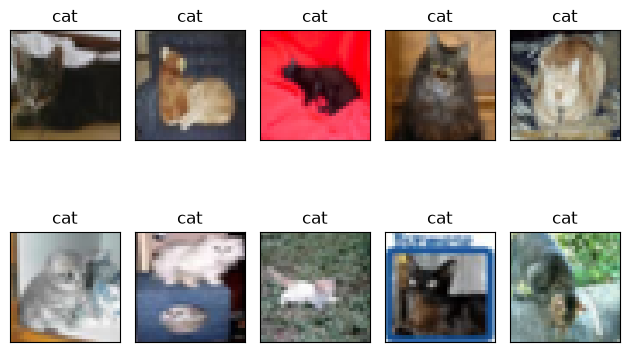

In [5]:
# View 10 images from 1 class
fig, ax = plt.subplots(nrows=2, ncols=5)
ax = ax.flatten()

for i in range(10):
    label_idx = 3
    label = label_map["label_names"][label_idx]
    img = np.transpose(X_train[Y_train==label_idx][i], axes=(1, 2, 0))
    ax[i].imshow(img)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(label)

plt.tight_layout()
plt.show()

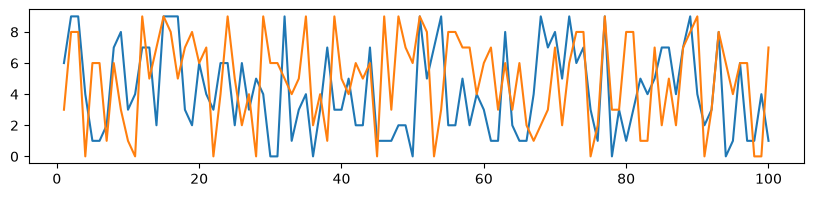

In [6]:
# Image labels are randomly shuffled
plt.figure(figsize=(10, 2))
plt.plot(np.arange(1, Y_train[:100].shape[0]+1), Y_train[:100])
plt.plot(np.arange(1, Y_test[:100].shape[0]+1), Y_test[:100])
plt.show()

# **Load Train and Test Data for Experiment**

Number of samples:
- Training : 5000
- Testing  : 500 

In [7]:
# Sample of Train and Test data
num_samples_train = 5000
num_samples_test = 100

np.random.seed(42)
train_idxs = np.random.randint(0, X_train.shape[0], num_samples_train)
test_idxs = np.random.randint(0, X_test.shape[0], num_samples_test)

X_tr = X_train[train_idxs]
Y_tr = Y_train[train_idxs]

X_ts = X_test[test_idxs]
Y_ts = Y_test[test_idxs]

print(X_tr.shape, Y_tr.shape)
print(X_ts.shape, Y_ts.shape)

# Flatten
X_tr = X_tr.reshape(num_samples_train, -1)
X_ts = X_ts.reshape(num_samples_test, -1)

print(X_tr.shape, Y_tr.shape)
print(X_ts.shape, Y_ts.shape)

(5000, 3, 32, 32) (5000,)
(100, 3, 32, 32) (100,)
(5000, 3072) (5000,)
(100, 3072) (100,)


# **Distances b/w vectors: KNN Distance computation**

3 ways to do this:
- Find distance b/w a single pair of test and train vectors (needs 2 loops)
- Find distance b/w a single test vector and #tr of train vectors (needs 1 loop)
- Find distance b/w (#ts) test vectors and (#tr) of train vectors (needs 0 loop)

## **Distances b/w vectors: KNN Distance computation-pt1**

In [8]:
v1 = np.array([1, 30])
v2 = np.array([50, 20])

print(v1.shape)
print(v2.shape)


a0 = v1-v2
a1 = np.abs(a0)
a2 = a1**2
a3 = a2.sum(axis=-1)
a4 = np.sqrt(a3)


print(a0)
print(a1)
print(a2)
print(a3)
print(a4)

(2,)
(2,)
[-49  10]
[49 10]
[2401  100]
2501
50.00999900019995


## **Distances b/w vectors: KNN Distance computation-pt2**

In [9]:
v1 = np.array([1, 30])
v2 = np.array([[50, 20], [30, 40], [-9, 4]])

print(v1.shape)
print(v2.shape)

# numpy Broadcasting in action
a0 = v1-v2
print(a0)

(2,)
(3, 2)
[[-49  10]
 [-29 -10]
 [ 10  26]]


In [10]:
# ============================================================
# NumPy Broadcasting Cheat Sheet
# ============================================================
#
# Broadcasting enables element-wise operations on arrays of
# different shapes without explicitly copying data.
#
# Rules
# -----
# 1. Align shapes from the RIGHT (pad smaller shape with leading 1's).
# 2. For each axis, dimensions are compatible if:
#       ✓ Equal
#       ✓ One of them is 1
#       ✗ Otherwise -> ValueError
# 3. Result dimension = max(dimA, dimB)
# 4. Size-1 dimensions are conceptually stretched (no actual copy).
#
# ------------------------------------------------------------
# Examples
# ------------------------------------------------------------
#
# (4,3)     + (4,3)      -> (4,3)      ✓ Same shape
#
# (2,3)     + (3,)       -> (2,3)
# Pad: (2,3) + (1,3)
#
# (2,1)     + (1,3)      -> (2,3)
# Column vector + Row vector
#
# (8,1,6,1) + (7,1,5)    -> (8,7,6,5)
# Pad: (8,1,6,1)
#      (1,7,1,5)
# Axis-wise: 8/1 → 8, 1/7 → 7, 6/1 → 6, 1/5 → 5
#
# (5,4,3)   + (3,)       -> (5,4,3)
# Pad: (5,4,3) + (1,1,3)
#
# (4,5)     + ()         -> (4,5)
# Scalar broadcasts to every element.
#
# ------------------------------------------------------------
# Invalid Cases
# ------------------------------------------------------------
#
# (4,3) + (4,)
# Pad: (4,3) + (1,4)
# 3 vs 4 -> ❌ Error
#
# (2,3) + (2,2)
# 3 vs 2 -> ❌ Error
#
# ------------------------------------------------------------
# Mental Algorithm
# ------------------------------------------------------------
#
# Pad with leading 1's
#      ↓
# Compare RIGHT → LEFT
#      ↓
# Equal or 1 ? → Yes
#      ↓
# Take max(dimA, dimB)
#      ↓
# Otherwise → ValueError
#
# Memory Trick:
# "Pad → Compare → Equal/1 → Take Max → Else Error"
# ============================================================

In [11]:
v1 = np.array([1, 30])
v2 = np.array([[50, 20], [30, 40], [-9, 4]])

print(v1.shape)
print(v2.shape)
print('-'*50)

arr = [0]*10
arr[0] = v1-v2
arr[1] = np.abs(arr[0])**2
arr[2] = arr[1].sum(axis=-1)
arr[3] = arr[1].sum(axis=-1, keepdims=True)
arr[4] = np.sqrt(arr[2])


for i in range(5):
    print(arr[i])
    print('-'*50)

(2,)
(3, 2)
--------------------------------------------------
[[-49  10]
 [-29 -10]
 [ 10  26]]
--------------------------------------------------
[[2401  100]
 [ 841  100]
 [ 100  676]]
--------------------------------------------------
[2501  941  776]
--------------------------------------------------
[[2501]
 [ 941]
 [ 776]]
--------------------------------------------------
[50.009999   30.6757233  27.85677655]
--------------------------------------------------


## **Distances b/w vectors: KNN Distance computation-pt3**

- Broadcast with singleton dimension

In [12]:
v1 = np.array([[10, 20], [30, 40]])
v2 = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])

print(v1.shape)
print(v2.shape)
print('-'*50)

v1b = np.expand_dims(v1, axis=1)
v2b = np.expand_dims(v2, axis=0)

print(v1b.shape)
print(v2b.shape)
print('-'*50)


arr = [0]*10
arr[0] = v1b-v2b
arr[1] = np.abs(arr[0])**2
arr[2] = arr[1].sum(axis=-1)
arr[3] = arr[1].sum(axis=-1, keepdims=True)
arr[4] = np.sqrt(arr[2])

for i in range(5):
    print(arr[i])
    print('-'*50)


(2, 2)
(4, 2)
--------------------------------------------------
(2, 1, 2)
(1, 4, 2)
--------------------------------------------------
[[[ 9 18]
  [ 7 16]
  [ 5 14]
  [ 3 12]]

 [[29 38]
  [27 36]
  [25 34]
  [23 32]]]
--------------------------------------------------
[[[  81  324]
  [  49  256]
  [  25  196]
  [   9  144]]

 [[ 841 1444]
  [ 729 1296]
  [ 625 1156]
  [ 529 1024]]]
--------------------------------------------------
[[ 405  305  221  153]
 [2285 2025 1781 1553]]
--------------------------------------------------
[[[ 405]
  [ 305]
  [ 221]
  [ 153]]

 [[2285]
  [2025]
  [1781]
  [1553]]]
--------------------------------------------------
[[20.1246118  17.4642492  14.86606875 12.36931688]
 [47.80167361 45.         42.20189569 39.40812099]]
--------------------------------------------------


## **Check distance array - should be same for all 3 cases** 


In [13]:
import time
from src.classifiers.knn import KNearestNeighbor

In [14]:
# Instantiate and train the knn model
knn_model = KNearestNeighbor()
knn_model.train(X_tr, Y_tr)

In [15]:
def timer(func, *args, **kwargs):
    start = time.perf_counter()
    result, _ = func(*args, **kwargs)
    end = time.perf_counter()
    print(f"Elapsed time for num_loops={kwargs['num_loops']}: {end-start:.6f} s")
    return result, round(end-start, 6)

dist_2, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=2)
dist_1, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=1)
dist_0, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=0, use_matmul=False)

print(dist_2.shape)
print(dist_1.shape)
print(dist_0.shape)

Elapsed time for num_loops=2: 1.713840 s
Elapsed time for num_loops=1: 1.294614 s
Elapsed time for num_loops=0: 2.841184 s
(100, 5000)
(100, 5000)
(100, 5000)


In [16]:
print(np.all(dist_2==dist_1, axis=None))
print(np.all(dist_2==dist_0, axis=None))

True
True


## **Distances b/w vectors: KNN Distance computation-pt3**

- Use Vectorized Implementation (See Scrible Notes)

In [17]:
# Sample of Train and Test data
num_samples_train = 5000
num_samples_test = 50

np.random.seed(42)
train_idxs = np.random.randint(0, X_train.shape[0], num_samples_train)
test_idxs = np.random.randint(0, X_test.shape[0], num_samples_test)

X_tr = X_train[train_idxs]
Y_tr = Y_train[train_idxs]

X_ts = X_test[test_idxs]
Y_ts = Y_test[test_idxs]

print(X_tr.shape, Y_tr.shape)
print(X_ts.shape, Y_ts.shape)

# Flatten
X_tr = X_tr.reshape(num_samples_train, -1)
X_ts = X_ts.reshape(num_samples_test, -1)

# Very Important - X_tr is originally in np.uint8, wil cause overflow in vectorized code since we are doing X_tr**2
X_tr = X_tr.astype(np.int32)
X_ts = X_ts.astype(np.int32)

print(X_tr.shape, Y_tr.shape)
print(X_ts.shape, Y_ts.shape)

(5000, 3, 32, 32) (5000,)
(50, 3, 32, 32) (50,)
(5000, 3072) (5000,)
(50, 3072) (50,)


In [18]:
# Instantiate and train the knn model
knn_model = KNearestNeighbor()
knn_model.train(X_tr, Y_tr)

dist_2, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=2)
dist_1, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=1)
dist_0_nonvec, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=0, use_matmul=False)
dist_0_vec, _ = timer(knn_model.predict, X=X_ts, k=1, num_loops=0, use_matmul=True)

print(dist_2.shape)
print(dist_1.shape)
print(dist_0_nonvec.shape)
print(dist_0_vec.shape)

Elapsed time for num_loops=2: 1.047712 s
Elapsed time for num_loops=1: 1.190249 s
Elapsed time for num_loops=0: 4.606424 s
Elapsed time for num_loops=0: 0.304445 s
(50, 5000)
(50, 5000)
(50, 5000)
(50, 5000)


In [19]:
print(np.all(dist_2==dist_1, axis=None))
print(np.all(dist_2==dist_0_nonvec, axis=None))
print(np.all(dist_2==dist_0_vec, axis=None))

True
True
True


# **Predict labels**

- Use np.arsort to find topk closest training samples for each test sample
- Take the majority label from the topk training samples as final answer

In [20]:
closest_y = []
test_labels = np.array([1, 0, 2, 5, 2, 6, 0, 1])
test_dist = np.array([100, 150, 87, 4, 65, 71, 98, 23])
test_dist_sorted_idx = np.argsort(test_dist)
print(test_dist_sorted_idx)
print(test_dist[test_dist_sorted_idx])
print(test_labels[test_dist_sorted_idx])

closest_y = test_labels[test_dist_sorted_idx][:2]
print(closest_y)


[3 7 4 5 2 6 0 1]
[  4  23  65  71  87  98 100 150]
[5 1 2 6 2 0 1 0]
[5 1]


In [42]:
# Sample of Train and Test data
num_samples_train = 5000
num_samples_test = 500

np.random.seed(42)
train_idxs = np.random.randint(0, X_train.shape[0], num_samples_train)
test_idxs = np.random.randint(0, X_test.shape[0], num_samples_test)

X_tr = X_train[train_idxs]
Y_tr = Y_train[train_idxs]

X_ts = X_test[test_idxs]
Y_ts = Y_test[test_idxs]

print(X_tr.shape, Y_tr.shape)
print(X_ts.shape, Y_ts.shape)

# Flatten
X_tr = X_tr.reshape(num_samples_train, -1)
X_ts = X_ts.reshape(num_samples_test, -1)

# Very Important - X_tr is originally in np.uint8, wil cause overflow in vectorized code since we are doing X_tr**2
X_tr = X_tr.astype(np.int32)
X_ts = X_ts.astype(np.int32)

print(X_tr.shape, Y_tr.shape)
print(X_ts.shape, Y_ts.shape)

(5000, 3, 32, 32) (5000,)
(500, 3, 32, 32) (500,)
(5000, 3072) (5000,)
(500, 3072) (500,)


In [43]:
# Instantiate and train the knn model
knn_model = KNearestNeighbor()
knn_model.train(X_tr, Y_tr)

# Predict on Xts
dists, preds = knn_model.predict(X_ts, k=1, num_loops=0, use_matmul=True)

In [44]:
acc = (preds==Y_ts).sum()/len(Y_ts)
print(f"Total Test Samples: {len(Y_ts)}")
print(f"Accuracy: {acc}")

Total Test Samples: 500
Accuracy: 0.266
